In [804]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [805]:
df = pd.read_csv(r"C:\Users\USER\Downloads\college_major_roi.csv")

In [806]:
#Checking Data
pd.set_option('display.float_format', lambda x: '%.6f' % x)
df.head()

,grad_id,major,major_category,institution_tier,institution_selectivity_pctile,gpa,had_internship,completed_on_time,region,net_cost_usd,debt_usd,hs_baseline_10yr_usd,added_earnings_10yr_usd,earnings_10yr_usd,net_roi_usd,roi_pct,positive_roi,high_roi
0,G000000,biology,STEM,mid_tier,52,2.580000,0,0,south,144400,0,411700,101000,512700,-43400,-30.000000,0,0
1,G000001,marketing,business,mid_tier,61,2.580000,0,1,northeast,57400,0,356900,330600,687500,273200,476.100000,1,0
2,G000002,electrical_engineering,STEM,top_public,78,3.140000,1,1,northeast,65100,39600,339600,655100,994700,590000,906.400000,1,1
3,G000003,marketing,business,top_public,77,3.040000,0,1,midwest,105800,81300,399600,197500,597100,91700,86.800000,1,0
4,G000004,marketing,business,ivy_elite,100,3.810000,0,0,south,219200,93500,335700,222900,558600,3800,1.700000,1,0


In [807]:
#Making Institution_Tier an interger
institution_map = {"for_profit" : 1, "regional" : 2, "mid_tier" : 3, "top_public" : 4, "ivy_elite" : 5}
df["institution_tier"] = df["institution_tier"].map(institution_map)

In [808]:
#Making Institution_Tier interger
df["institution_tier"].head()

0    3
1    3
2    4
3    4
4    5
Name: institution_tier, dtype: int64

In [809]:
#Making Major Category an interger
major_map = {"STEM" : 7, "business" : 6, "social_science" : 5, "education" : 4, "health" : 3, "arts" : 2, "humanities" : 1}
df["major_category"] = df["major_category"].map(major_map)

In [810]:
#Making Major Category an interger
df["major_category"].head()

0    7
1    6
2    7
3    6
4    6
Name: major_category, dtype: int64

In [811]:
df.dtypes

grad_id                               str
major                                 str
major_category                      int64
institution_tier                    int64
institution_selectivity_pctile      int64
gpa                               float64
had_internship                      int64
completed_on_time                   int64
region                                str
net_cost_usd                        int64
debt_usd                            int64
hs_baseline_10yr_usd                int64
added_earnings_10yr_usd             int64
earnings_10yr_usd                   int64
net_roi_usd                         int64
roi_pct                           float64
positive_roi                        int64
high_roi                            int64
dtype: object

In [812]:
#Checking all the majors
print(df["major"].unique())

<StringArray>
[               'biology',              'marketing', 'electrical_engineering',
               'business',              'economics',            'social_work',
 'mechanical_engineering',                'finance',   'computer_engineering',
              'education',   'chemical_engineering',         'communications',
       'computer_science',                'nursing',       'criminal_justice',
              'fine_arts',             'humanities',             'psychology',
     'business_analytics']
Length: 19, dtype: str


In [813]:
#Checking Null and Na
df.isnull().sum()

grad_id                           0
major                             0
major_category                    0
institution_tier                  0
institution_selectivity_pctile    0
gpa                               0
had_internship                    0
completed_on_time                 0
region                            0
net_cost_usd                      0
debt_usd                          0
hs_baseline_10yr_usd              0
added_earnings_10yr_usd           0
earnings_10yr_usd                 0
net_roi_usd                       0
roi_pct                           0
positive_roi                      0
high_roi                          0
dtype: int64

In [814]:
df.isna().sum()

grad_id                           0
major                             0
major_category                    0
institution_tier                  0
institution_selectivity_pctile    0
gpa                               0
had_internship                    0
completed_on_time                 0
region                            0
net_cost_usd                      0
debt_usd                          0
hs_baseline_10yr_usd              0
added_earnings_10yr_usd           0
earnings_10yr_usd                 0
net_roi_usd                       0
roi_pct                           0
positive_roi                      0
high_roi                          0
dtype: int64

In [815]:
#Checking For Active Students
condition = (df["had_internship"] == 1) & (df["completed_on_time"] == 1)
df["student_was_active"] = np.where(condition, 1, 0)

In [816]:
print(df["student_was_active"].head())

0    0
1    0
2    1
3    0
4    0
Name: student_was_active, dtype: int64


In [817]:
#Exploring the datas
condition = (df["student_was_active"] == 1) & (df["major_category"] == 7)
df["stem_active"] = np.where(condition, 1, 0)

In [818]:
df["stem_active"].head(20)

0     0
1     0
2     1
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    1
17    0
18    0
19    0
Name: stem_active, dtype: int64

In [819]:
condition = (df["student_was_active"] == 1) & (df["major_category"] != 7)
df["non_stem_active"] = np.where(condition, 1, 0)

In [820]:
print(df["non_stem_active"].head(20))

0     0
1     0
2     0
3     0
4     0
5     0
6     1
7     1
8     0
9     0
10    1
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
Name: non_stem_active, dtype: int64


In [821]:
#Exploring the income ROI for active STEM students and non-active STEM students
df["non_stem_roi"] = np.where((df["non_stem_active"] == 1), df["net_roi_usd"], 0)

In [822]:
#remove zero values
df["non_stem_roi"].head(30)

0          0
1          0
2          0
3          0
4          0
5          0
6     365800
7     103100
8          0
9          0
10    374900
11         0
12         0
13         0
14         0
15         0
16         0
17         0
18         0
19         0
20    251000
21         0
22     29600
23         0
24         0
25         0
26         0
27         0
28         0
29         0
Name: non_stem_roi, dtype: int64

In [823]:
df["non_stem_roi_new"] = df["net_roi_usd"][df["non_stem_roi"] !=0]

In [824]:
df["non_stem_roi_new"].isnull().sum()

np.int64(24344)

In [825]:
df["non_stem_roi_new"] = df["non_stem_roi_new"].dropna()

In [826]:
df["stem_roi"] = np.where((df["stem_active"] == 1), df["net_roi_usd"], 0)

In [827]:
df["stem_roi"].head()

0         0
1         0
2    590000
3         0
4         0
Name: stem_roi, dtype: int64

In [828]:
df["stem_roi"].head(30)

0          0
1          0
2     590000
3          0
4          0
5          0
6          0
7          0
8          0
9          0
10         0
11         0
12         0
13         0
14         0
15         0
16    550300
17         0
18         0
19         0
20         0
21         0
22         0
23         0
24    378100
25         0
26    565500
27    973300
28         0
29         0
Name: stem_roi, dtype: int64

In [829]:
df["stem_roi_new"] = df["net_roi_usd"][df["stem_roi"] !=0]

In [830]:
df["stem_roi_new"].head(10)

0             NaN
1             NaN
2   590000.000000
3             NaN
4             NaN
5             NaN
6             NaN
7             NaN
8             NaN
9             NaN
Name: stem_roi_new, dtype: float64

In [831]:
df["stem_roi_new"] = df["stem_roi_new"].dropna()

In [832]:
#Getting The Average ROI For Active STEM and Non-STEM Students
print(f"Here is the data for active STEM Students: {df["stem_roi_new"].describe()}")

Here is the data for active STEM Students: count      3267.000000
mean     507268.258341
std      315119.450975
min      -36300.000000
25%      280350.000000
50%      452300.000000
75%      670850.000000
max     2342400.000000
Name: stem_roi_new, dtype: float64


In [833]:
#Getting The Average ROI For Active STEM and Non-STEM Students
print(f"Here is the data for active STEM Students: {df["non_stem_roi_new"].describe()}")

Here is the data for active STEM Students: count      5656.000000
mean     242596.782178
std      274937.460141
min     -142100.000000
25%       31275.000000
50%      162550.000000
75%      384050.000000
max     2755100.000000
Name: non_stem_roi_new, dtype: float64


In [834]:
#Finding correlation between active STEM or Non-STEM students on the ROI
corr_df = df[["stem_active", "non_stem_active", "positive_roi", "high_roi"]]

In [835]:
corr_matrix = corr_df.corr()

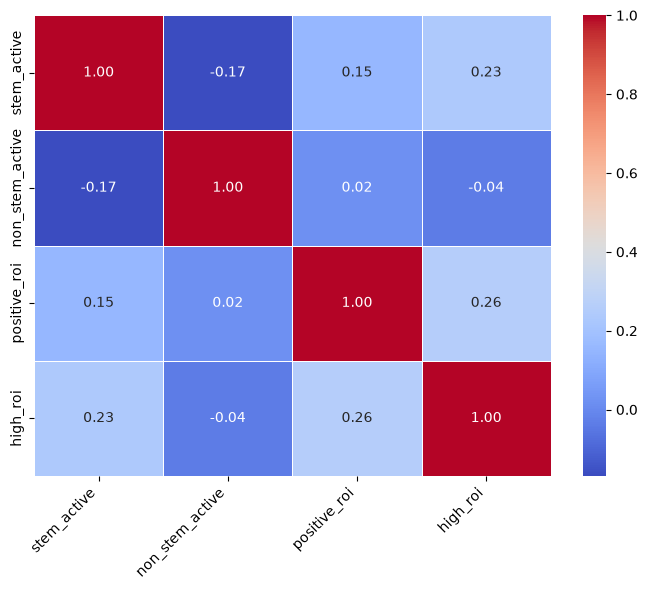

In [836]:
# Make The Plot
plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [837]:
#Making Linear Regression
future_x = df.drop(columns=['major', 'grad_id', 'region', 'stem_roi_new', 'non_stem_roi_new', 'stem_active', 'non_stem_active', 'net_cost_usd', 
                     'earnings_10yr_usd', 'added_earnings_10yr_usd', 'hs_baseline_10yr_usd','roi_pct', 'positive_roi', 'high_roi', 
                     'non_stem_roi', 'stem_roi', 'net_roi_usd'])
X = future_x
y = df["net_roi_usd"]


In [838]:
model_reg = sm.OLS(y, X).fit()

In [839]:
print(model_reg.summary())

                                 OLS Regression Results                                
Dep. Variable:            net_roi_usd   R-squared (uncentered):                   0.599
Model:                            OLS   Adj. R-squared (uncentered):              0.599
Method:                 Least Squares   F-statistic:                              5598.
Date:                Thu, 24 Sep 2026   Prob (F-statistic):                        0.00
Time:                        15:26:03   Log-Likelihood:                     -4.1568e+05
No. Observations:               30000   AIC:                                  8.314e+05
Df Residuals:                   29992   BIC:                                  8.314e+05
Df Model:                           8                                                  
Covariance Type:            nonrobust                                                  
                                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------

In [840]:
#Ambil data dari Regresi Linear Diatas dan buat jadi dataframe dan di dibuat ringkasan
each_results_table = model_reg.summary().tables[1]
my_dataframe = pd.DataFrame(each_results_table.data[1:], columns=each_results_table.data[0])
my_dataframe['coef'] = pd.to_numeric(my_dataframe['coef'], errors='coerce')
pd.set_option('display.float_format', lambda x: '{:,.1f}'.format(x))

print(my_dataframe)

                                       coef    std err          t   P>|t|  \
0                  major_category  71,750.0    808.219     88.773   0.000   
1                institution_tier  81,870.0   6457.443     12.679   0.000   
2  institution_selectivity_pctile  -2,152.2    359.485     -5.987   0.000   
3                             gpa -84,550.0   1949.151    -43.380   0.000   
4                  had_internship  46,450.0   5133.295      9.049   0.000   
5               completed_on_time  25,120.0   4077.577      6.160   0.000   
6                        debt_usd      -0.4      0.039    -10.446   0.000   
7              student_was_active  29,490.0   6229.488      4.733   0.000   

      [0.025     0.975]  
0   7.02e+04   7.33e+04  
1   6.92e+04   9.45e+04  
2  -2856.813  -1447.599  
3  -8.84e+04  -8.07e+04  
4   3.64e+04   5.65e+04  
5   1.71e+04   3.31e+04  
6     -0.485     -0.332  
7   1.73e+04   4.17e+04  
